Modified code to check for different resolutions.

# Burgers Equation

Given the Burgers’ equation in 1D $ \frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0 $ build a numerical code to solve it on a grid
with extent x ∈ [0, 10] and with initial conditions given by
$$ u(x, t = 0) = 10 e^{−(x−x_0)^2} \, \, , $$
with $x_0 = 5$. Compute the solution using both the flux-conservative and the non flux-
conservative versions of the upwind scheme. Use Courant factor $cf = 0.5$, a grid with at least
$J = 101$ points with periodic boundary conditions, and terminate the evolution at $t = 0.5$.
Compare the solutions computed with the two different methods by plotting $u(x, t)$ at different
times (including $t = 0.5$). What happens when you increase the resolution?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(['science', 'grid', 'high-contrast', 'no-latex'])

In [2]:
#domain ---------------------------
L = 10.0         #domain length
nx = np.array([101, 151, 301])         #number of points
dx = L/(nx-1)    #grid space
x = [np.linspace(0, L, ni) for ni in nx]

#initial conditions ---------------
x0 = 5
u_initial = [10 * np.exp(- (xi - x0)**2 ) for xi in x]
u_current = [np.copy(u_i) for u_i in u_initial]

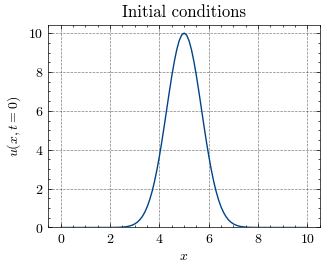

In [3]:
plt.plot(x[0], u_initial[0])
plt.xlabel("$x$")
plt.ylabel("$u(x, t=0)$")
plt.ylim(0, 10.4)
plt.title("Initial conditions")
#plt.savefig('initial.png', dpi=200)
plt.show()

Unlike the Advection equation, the solution is not the same function moving at a constant speed a. Thus the time step is not a constant anymore in theory, and should evolve in time. For now, we can select the maximum of $u(t=0, x)$ and use it as a constant speed. Since the time step is inversely proportional to the speed, using the maximum speed guarantees that the CFL condition is satified everywhere.
This works because we know that the maximum is going down, otherwise we should recompute the dt at each iteration.

In [4]:
#time step ------------------------
cf = 0.5
a = [np.max(u_c) for u_c in u_current]
dt = cf * dx/a
t_final = 0.5

print('nx=',nx)
print('dx=',dx)
print('dt=',dt)
print('Number of iterations=',t_final/dt)

nx= [101 151 301]
dx= [0.1        0.06666667 0.03333333]
dt= [0.005      0.00333333 0.00166667]
Number of iterations= [100. 150. 300.]


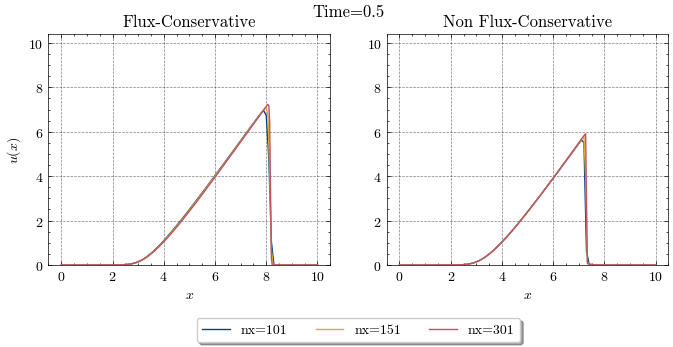

In [5]:
fig, ax = plt.subplots(1, 2, figsize = (8,3))
ax[0].set(xlabel = "$x$", ylabel = "$u(x)$", title = "Flux-Conservative", ylim = [0, 10.4])
ax[1].set(xlabel = "$x$", title = "Non Flux-Conservative", ylim = [0, 10.4])

u_current = [np.copy(u_i) for u_i in u_initial]

for j in range(3):
    t = 0.0
    i = 0
    
    time = []
    time.append(0.0)
    
    t_10 = True #to save the plots at t = 0.1
    t_30 = True #t = 0.3

    while t <= t_final:
        u_next = u_current[j] - dt[j]/(2*dx[j]) *(u_current[j]**2 - np.roll(u_current[j], +1)**2)
        u_current[j] = u_next.copy()

        t += dt[j]
        i += 1

        if (t >= 0.1 and t_10): 
            fc_u_10= u_current[j].copy()
            t_10 = False
        if (t >= 0.3 and t_30): 
            fc_u_30 = u_current[j].copy()
            t_30 = False
    
    ax[0].plot(x[j], u_current[j], label = 'nx=' + str(nx[j]))

ax[0].legend(loc='upper center', bbox_to_anchor=(1.1, -0.2),
          fancybox=True, shadow=True, ncol=3)


u_current = [np.copy(u_i) for u_i in u_initial]

for j in range(3):
    t = 0.0
    i = 0
    
    time = []
    time.append(0.0)
    
    t_10 = True #to save the plots at t = 0.1
    t_30 = True #t = 0.3

    while t <= t_final:
        u_next = u_current[j] - dt[j]/dx[j] * u_current[j] * (u_current[j] - np.roll(u_current[j], +1))
        u_current[j] = u_next.copy()

        t += dt[j]
        i += 1

        if (t >= 0.1 and t_10): 
            nfc_u_10= u_current[j].copy()
            t_10 = False
        if (t >= 0.3 and t_30): 
            nfc_u_30 = u_current[j].copy()
            t_30 = False
    
    ax[1].plot(x[j],u_current[j])


plt.suptitle('Time=0.5')
plt.savefig('res_t0_5bb.png', dpi = 200)
plt.show()
